In [ ]:
# !git clone -b QCNN_integration https://github.com/merQlab/geqie.git

Cloning into 'geqie'...
remote: Enumerating objects: 1751, done.
remote: Counting objects: 100% (514/514), done.
remote: Compressing objects: 100% (191/191), done.
remote: Total 1751 (delta 386), reused 331 (delta 323), pack-reused 1237 (from 1)
Receiving objects: 100% (1751/1751), 53.10 MiB | 26.51 MiB/s, done.
Resolving deltas: 100% (968/968), done.


In [2]:
%cd ..

e:\Programowanko\Geqie\geqie


In [1]:
%cd geqie

[WinError 2] The system cannot find the file specified: 'geqie'
e:\Programowanko\Geqie\geqie\experiments\QCNN_integration


In [4]:
# !pip install -r requirements/requirements.txt --quiet

In [5]:
# !pip install .

In [ ]:
# !pip install qiskit_machine_learning --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 10.0 MB/s eta 0:00:00


In [3]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np
from torch import Tensor
from torch.nn import Linear, CrossEntropyLoss, MSELoss
from torch.optim import LBFGS
from matplotlib.colors import ListedColormap
from PIL import Image

In [4]:
# Load & process MNIST dataset:

from datasets import load_dataset
import os

current_dir = os.getcwd()
mnist_dataset = os.path.join("train-00000-of-00001.parquet")
# mnist_dataset = os.path.join(".MNIST_digits", "mnist", "train-00000-of-00001.parquet")
path_to_mnist_dataset = os.path.join(current_dir, mnist_dataset)

def load_and_process_mnist_dataset(labels_to_include=[0, 1], n_samples_per_label=100, resize=(8, 8)):
	mnist_dataset = load_dataset("parquet", data_files=path_to_mnist_dataset)

	selected_images = []
	for image_idx in range(len(mnist_dataset["train"])):
		# First, select only images with labels in labels_to_include:

		if mnist_dataset["train"][image_idx]["label"] in labels_to_include:
			img_8x8 = mnist_dataset["train"][image_idx]["image"].resize(resize, resample=Image.BILINEAR)
			img = np.array(img_8x8)
			selected_images.append({"image": img, "label": mnist_dataset["train"][image_idx]["label"]})

	X = np.array([item["image"] for item in selected_images])
	y = np.array([item["label"] for item in selected_images])

	return X, y

X, y = load_and_process_mnist_dataset(labels_to_include=[0, 1], n_samples_per_label=100, resize=(16, 16))

c:\Python\QML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import time

import glob
import torch
import numpy as np
import torch.nn as nn
from torch.nn import Linear, CrossEntropyLoss, MSELoss, NLLLoss
from torch.optim import LBFGS, Adam
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit import CircuitInstruction
from qiskit.circuit.library import UnitaryGate
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient

import geqie
from geqie.encodings import frqi

# Define the gradient explicitly

class Simple_QNN:
	def __init__(self):
		'''
		Initialize the Simple_QNN class.
		This class takes as an input a quantum circuit with pre-encoded image from GEQIE.
		'''
		self.image: np.ndarray = None
		self.circuit: QuantumCircuit = None


	def encode_image_using_GEQIE(self, image:np.ndarray):
		'''Encode the input image using GEQIE encoding.'''
		self.image = image
		self.circuit = geqie.encode(frqi.init_function, frqi.data_function, frqi.map_function, image, perform_measurement=False)

	def append_CNOT_cascade(self):
		'''Append a cascade (stairs) of CNOT gates to the quantum circuit.'''
		num_qubits = self.circuit.num_qubits
		for i in range(num_qubits - 1):
			self.circuit.cx(i, i + 1)

		self.circuit.cx(self.circuit.num_qubits - 1, 0)

	def append_VQC_layer(self, thetas: ParameterVector):
		'''Append a variational quantum circuit (VQC) layer to the quantum circuit.'''
		num_qubits = self.circuit.num_qubits
		if len(thetas) != 3 * num_qubits:
			raise ValueError(f"Expected {3 * num_qubits} parameters, but got {len(thetas)}.")

		# First layer - RX gates:
		for i in range(num_qubits):
			self.circuit.rx(thetas[i], i)
		# Second layer - RY gates:
		for i in range(num_qubits):
			self.circuit.ry(thetas[i + num_qubits], i)
		# Third layer - RZ gates:
		for i in range(num_qubits):
			self.circuit.rz(thetas[i + 2 * num_qubits], i)


class QNN_Pythorch_Module(nn.Module):
	def __init__(self, num_classes):
		super().__init__()
		self.num_qubits = None
		self.num_classes = num_classes
		self.simple_qcnn: Simple_QNN = None
		self.thetas: ParameterVector = None
		self.simple_qnn_as_sampler_qnn: SamplerQNN = None
		self.layer_TorchConnector: TorchConnector = None
		self.weights = None


	def build_new_circuit(self, image: np.ndarray):
		'''Update the quantum circuit with the new image encoding.'''
		simple_qcnn = Simple_QNN()
		# GEQIE endcoding, and simple QNN:
		simple_qcnn.encode_image_using_GEQIE(image=image)
		self.num_qubits = simple_qcnn.circuit.num_qubits  # Update num_qubits based on the new circuit
		simple_qcnn.append_CNOT_cascade()
		thetas = ParameterVector("theta", length=3 * self.num_qubits)
		simple_qcnn.append_VQC_layer(thetas=thetas)
		self.thetas = thetas
		self.simple_qcnn = simple_qcnn

	def interpret_multiclass(self, outcome: int) -> int:
		return outcome % self.num_classes
	# def interpret_multiclass(self, outcome: int) -> int:
	# 	return outcome & 1


	def SimpleQNN_to_SamplerQNN(self):
		'''Convert the quantum circuit to a SamplerQNN.'''
		if self.thetas is None:
			raise ValueError("VQC parameters have not been set. Please build the circuit before calling conversion to SamplerQNN.")
		sampler = Sampler()
		gradient = ParamShiftSamplerGradient(sampler=sampler)
		self.simple_qnn_as_sampler_qnn = SamplerQNN(
			circuit=self.simple_qcnn.circuit,
			input_params=None,
			weight_params=self.thetas,
			output_shape=self.num_classes,
			sampler=sampler,
			gradient=gradient
		)

	def initialize(self, image: np.ndarray):
		self.build_new_circuit(image=image)
		self.SimpleQNN_to_SamplerQNN()
		self.SamplerQNN_to_TorchConnector()
		self.classical_head = nn.Linear(2**self.num_qubits, self.num_classes)
		self.weights = nn.Parameter(self.layer_TorchConnector.weight.data.clone())

	def update_geqie_unitary_matrix_inplace_in_Sampler(self, matrix):
		'''Update the GEQIE unitary matrix in-place with the new image encoding.'''
		# new_circuit:QuantumCircuit = geqie.encode(frqi.init_function, frqi.data_function, frqi.map_function, matrix, perform_measurement=False)

		# More robust: find instruction by name/type
		for idx, instruction in enumerate(self.simple_qnn_as_sampler_qnn.circuit.data):
			if instruction.operation.name == 'Unitary':  # Adjust based on actual operation name
				original = self.simple_qnn_as_sampler_qnn.circuit.data[idx]
				self.simple_qnn_as_sampler_qnn.circuit.data[idx] = CircuitInstruction(
					UnitaryGate(matrix), original.qubits, original.clbits)
				break

		# geqie_unitary_matrix, qargs, cargs = new_circuit.data[geqie_unitary_matrix_position]
		# self.simple_qnn_as_sampler_qnn.circuit.data[geqie_unitary_matrix_position] = CircuitInstruction(geqie_unitary_matrix, qargs, cargs)

	def SamplerQNN_to_TorchConnector(self):
		'''Convert the SamplerQNN to a TorchConnector for integration with PyTorch.'''
		self.layer_TorchConnector = TorchConnector(self.simple_qnn_as_sampler_qnn)

# working simple
	# def forward(self, x, label):
	# 	self.simple_qcnn.circuit = QuantumCircuit(self.num_qubits)  # blank circuit
	# 	if label == 1:
	# 		self.simple_qcnn.circuit.x(0)
	# 	self.simple_qcnn.append_CNOT_cascade()
	# 	thetas = ParameterVector("theta", length=3 * self.num_qubits)
	# 	self.simple_qcnn.append_VQC_layer(thetas=thetas)
	# 	self.thetas = thetas
	# 	self.SimpleQNN_to_SamplerQNN()

	# 	# old_weights = self.layer_TorchConnector.weight.data.clone()
	# 	self.SamplerQNN_to_TorchConnector()
	# 	self.layer_TorchConnector.weight.data.copy_(self.weights.data)

	# 	def grad_hook(grad):
	# 		self.weights.grad = grad.clone()
	# 	self.layer_TorchConnector.weight.register_hook(grad_hook)
	# 	# with torch.no_grad():
	# 	# 	self.layer_TorchConnector.weight.copy_(old_weights)

	# 	output = self.layer_TorchConnector()
	# 	return torch.log_softmax(output, dim=-1)

# original
	# def forward(self, x):
	# 	"""
	# 	This is not a standard forward method. Its input is an image encoded using GEQIE, and placed in cricuit.
	# 	So, the "forward" pass means just running the circuit with ansazt parameters and evaluating it.
	# 	"""
	# 	self.update_geqie_unitary_matrix_inplace_in_Sampler(new_image=x)
	# 	output = self.layer_TorchConnector()
	# 	return torch.log_softmax(output, dim=-1)

	def forward(self, x):
		self.update_geqie_unitary_matrix_inplace_in_Sampler(x)
		self.layer_TorchConnector.weight.data.copy_(self.weights.data)

		def grad_hook(grad):
			self.weights.grad = grad.clone()
		self.layer_TorchConnector.weight.register_hook(grad_hook)

		probs = self.layer_TorchConnector()
		logits = self.classical_head(probs)
		return torch.log_softmax(logits, dim=-1)


def train_QCNN(epochs=10, X=None, y=None, num_classes=2):
	f_loss = NLLLoss()
	qnn_model = QNN_Pythorch_Module(num_classes=num_classes)  # Example values for num_qubits and num_classes
	qnn_model.initialize(image=X[0])  # Build the circuit with the first image to initialize parameters
	with torch.no_grad():
		qnn_model.layer_TorchConnector.weight.uniform_(-0.1, 0.1)
	optimizer = Adam([
    {'params': qnn_model.weights},
    {'params': qnn_model.classical_head.parameters()}
], lr=0.03)
	# optimizer = Adam(qnn_model.classical_head.parameters(), lr=0.1)
	qnn_model.train()  # Set the model to training mode
	loss_list = []

	batch_files = sorted(glob.glob("circuits/batch_*.npz"))
	print("Training begins")
	for epoch in range(epochs):
		start = time.time()
		total_loss = []
		for batch_file in batch_files:
			data = np.load(batch_file)
			matrices = data["matrices"]
			labels = data["labels"]
			for matrix, label in zip(matrices, labels):
			# Wyzeruj gradient:
				optimizer.zero_grad()
				output = qnn_model(matrix)  # Forward pass
			# print(output.grad_fn)
				label_tensor = torch.tensor(label, dtype=torch.long)  # Scalar tensor for unbatched loss
				loss = f_loss(output, label_tensor)  # Calculate loss
				loss.backward()  # Backward pass
				optimizer.step()  # Optimize weights
				total_loss.append(loss.item())  # Store loss
			# print(qnn_model.layer_TorchConnector.weight.data[:3])

			# for name, param in qnn_model.named_parameters():
			# 	if param.grad is not None:
			# 		print(f"Layer: {name} | Gradient Mean: {param.grad.abs().mean().item()}")
			# 	else:
			# 		print(f"Layer: {name} | GRADIENT IS MISSING!")

			# print(f"label={label}: {loss}")
			# print()

		loss_list.append(sum(total_loss) / len(total_loss))
		print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss_list[-1]:.4f}")
		end = time.time()
		print(f"Time: {end - start:.2f}s")
		# print('='*25)
		# if (epoch + 1) % 10 == 0:
		# 	print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss_list[-1]:.4f}")
	return loss_list, qnn_model


ImportError: cannot import name 'Sampler' from 'qiskit.primitives' (c:\Python\QML\Lib\site-packages\qiskit\primitives\__init__.py)

In [6]:
import os
from qiskit.quantum_info import Operator

def precompute_and_save_circuits(X, y, batch_size=100, save_dir="circuits"):
  os.makedirs(save_dir, exist_ok=True)
  for batch_idx in range(0, len(X), batch_size):
    print(batch_idx)
    batch_X = X[batch_idx:batch_idx + batch_size]
    batch_y = y[batch_idx:batch_idx + batch_size]

    matrices = []
    for image in batch_X:
      new_circuit = geqie.encode(frqi.init_function, frqi.data_function, frqi.map_function, image, perform_measurement=False)
      geqie_gate = new_circuit.data[1].operation  # just the unitary gate
      matrix = geqie_gate.to_matrix().astype(np.complex64)
      matrices.append(matrix)

    np.savez(
            os.path.join(save_dir, f"batch_{batch_idx:06d}.npz"),
            matrices=np.array(matrices),
            labels=batch_y
        )

In [8]:
precompute_and_save_circuits(X[:20], y[:20], batch_size=5)

0
5
10
15


In [7]:
loss_history, trained_model = train_QCNN(epochs=25, X=X[:20], y=y[:20], num_classes=np.unique(y).shape[0])  # Train on a subset of the data for demonstration

C:\Users\kaswi\AppData\Local\Temp\ipykernel_2320\2698827362.py:110: DeprecationWarning: Sampler has been deprecated as of Aer 0.15, please use SamplerV2 instead.
  self.SimpleQNN_to_SamplerQNN()


Training begins


TypeError: Invalid circuits, expected Sequence[QuantumCircuit].

In [9]:
loss_history, trained_model = train_QCNN(epochs=25, X=X[:20], y=y[:20], num_classes=np.unique(y).shape[0])  # Train on a subset of the data for demonstration

Training begins
Epoch 1/25, Loss: 0.7008
Time: 29.02s
Epoch 2/25, Loss: 0.6847
Time: 44.08s
Epoch 3/25, Loss: 0.6839
Time: 48.90s
Epoch 4/25, Loss: 0.6852
Time: 28.96s
Epoch 5/25, Loss: 0.6847
Time: 29.43s
Epoch 6/25, Loss: 0.6862
Time: 31.72s
Epoch 7/25, Loss: 0.6827
Time: 38.03s
Epoch 8/25, Loss: 0.6837
Time: 33.98s
Epoch 9/25, Loss: 0.6829
Time: 31.18s
Epoch 10/25, Loss: 0.6864
Time: 31.04s
Epoch 11/25, Loss: 0.6828
Time: 32.43s
Epoch 12/25, Loss: 0.6835
Time: 33.47s
Epoch 13/25, Loss: 0.6836
Time: 32.57s
Epoch 14/25, Loss: 0.6843
Time: 29.88s
Epoch 15/25, Loss: 0.6840
Time: 30.55s
Epoch 16/25, Loss: 0.6894
Time: 29.35s
Epoch 17/25, Loss: 0.6869
Time: 30.93s
Epoch 18/25, Loss: 0.6859
Time: 30.13s
Epoch 19/25, Loss: 0.6852
Time: 29.79s
Epoch 20/25, Loss: 0.6865
Time: 30.69s
Epoch 21/25, Loss: 0.6854
Time: 31.83s
Epoch 22/25, Loss: 0.6860
Time: 32.65s
Epoch 23/25, Loss: 0.6833
Time: 32.40s
Epoch 24/25, Loss: 0.6851
Time: 31.87s
Epoch 25/25, Loss: 0.6868
Time: 29.00s


In [7]:
loss_history, trained_model = train_QCNN(epochs=25, X=X[:20], y=y[:20], num_classes=np.unique(y).shape[0])  # Train on a subset of the data for demonstration

Training begins
Epoch 1/25, Loss: 0.7510
Time: 82.79s
Epoch 2/25, Loss: 0.7172
Time: 80.84s
Epoch 3/25, Loss: 0.7103
Time: 83.96s
Epoch 4/25, Loss: 0.7161
Time: 82.12s
Epoch 5/25, Loss: 0.7156
Time: 81.13s
Epoch 6/25, Loss: 0.7158
Time: 82.87s
Epoch 7/25, Loss: 0.7082
Time: 82.71s
Epoch 8/25, Loss: 0.7148
Time: 81.91s
Epoch 9/25, Loss: 0.7143
Time: 80.42s
Epoch 10/25, Loss: 0.7122
Time: 80.76s
Epoch 11/25, Loss: 0.7238
Time: 81.67s
Epoch 12/25, Loss: 0.7134
Time: 81.09s
Epoch 13/25, Loss: 0.7141
Time: 82.12s
Epoch 14/25, Loss: 0.7051
Time: 83.11s
Epoch 15/25, Loss: 0.7219
Time: 83.92s
Epoch 16/25, Loss: 0.7178
Time: 82.69s
Epoch 17/25, Loss: 0.7108
Time: 82.04s
Epoch 18/25, Loss: 0.7165
Time: 82.58s
Epoch 19/25, Loss: 0.7133
Time: 82.16s
Epoch 20/25, Loss: 0.7127
Time: 85.59s
Epoch 21/25, Loss: 0.7152
Time: 82.58s
Epoch 22/25, Loss: 0.7077
Time: 84.04s


KeyboardInterrupt: 

In [ ]:
loss_history, trained_model = train_QCNN(epochs=25, X=X[:20], y=y[:20], num_classes=np.unique(y).shape[0])  # Train on a subset of the data for demonstration

Training begins
Epoch 1/25, Loss: 0.6946
Epoch 2/25, Loss: 0.6822
Epoch 3/25, Loss: 0.6792
Epoch 4/25, Loss: 0.6774
Epoch 5/25, Loss: 0.6776
Epoch 6/25, Loss: 0.6769
Epoch 7/25, Loss: 0.6766
Epoch 8/25, Loss: 0.6769
Epoch 9/25, Loss: 0.6769
Epoch 10/25, Loss: 0.6768
Epoch 11/25, Loss: 0.6766
Epoch 12/25, Loss: 0.6766
Epoch 13/25, Loss: 0.6770
Epoch 14/25, Loss: 0.6758
Epoch 15/25, Loss: 0.6764
Epoch 16/25, Loss: 0.6756
Epoch 17/25, Loss: 0.6758
Epoch 18/25, Loss: 0.6767


KeyboardInterrupt: 

In [ ]:
loss_history, trained_model = train_QCNN(epochs=25, X=X[:20], y=y[:20], num_classes=np.unique(y).shape[0])  # Train on a subset of the data for demonstration

Training begins
Epoch 1/25, Loss: 0.7586
Epoch 2/25, Loss: 0.7277
Epoch 3/25, Loss: 0.7284
Epoch 4/25, Loss: 0.7255
Epoch 5/25, Loss: 0.7137
Epoch 6/25, Loss: 0.7284
Epoch 7/25, Loss: 0.7232
Epoch 8/25, Loss: 0.7415
Epoch 9/25, Loss: 0.7312
Epoch 10/25, Loss: 0.7257
Epoch 11/25, Loss: 0.7381
Epoch 12/25, Loss: 0.7437
Epoch 13/25, Loss: 0.7426


KeyboardInterrupt: 

In [ ]:
loss_history, trained_model = train_QCNN(epochs=25, X=X[:20], y=y[:20], num_classes=np.unique(y).shape[0])  # Train on a subset of the data for demonstration

Training begins
Epoch 1/25, Loss: 0.6949
Epoch 2/25, Loss: 0.6825
Epoch 3/25, Loss: 0.6788
Epoch 4/25, Loss: 0.6781
Epoch 5/25, Loss: 0.6771
Epoch 6/25, Loss: 0.6769
Epoch 7/25, Loss: 0.6770
Epoch 8/25, Loss: 0.6767
Epoch 9/25, Loss: 0.6767
Epoch 10/25, Loss: 0.6773
Epoch 11/25, Loss: 0.6759
Epoch 12/25, Loss: 0.6763
Epoch 13/25, Loss: 0.6778
Epoch 14/25, Loss: 0.6767
Epoch 15/25, Loss: 0.6755
Epoch 16/25, Loss: 0.6766


KeyboardInterrupt: 

In [ ]:
loss_history, trained_model = train_QCNN(epochs=25, X=X[:20], y=y[:20], num_classes=np.unique(y).shape[0])  # Train on a subset of the data for demonstration

Epoch 1/25, Loss: 0.6919
Epoch 2/25, Loss: 0.6809
Epoch 3/25, Loss: 0.6789
Epoch 4/25, Loss: 0.6775
Epoch 5/25, Loss: 0.6762
Epoch 6/25, Loss: 0.6771
Epoch 7/25, Loss: 0.6771
Epoch 8/25, Loss: 0.6763
Epoch 9/25, Loss: 0.6759
Epoch 10/25, Loss: 0.6767


In [ ]:
loss_history, trained_model = train_QCNN(epochs=25, X=X[:20], y=y[:20], num_classes=np.unique(y).shape[0])  # Train on a subset of the data for demonstration

Epoch 1/25, Loss: 0.7006
Epoch 2/25, Loss: 0.6981
Epoch 3/25, Loss: 0.6939
Epoch 4/25, Loss: 0.6989
Epoch 5/25, Loss: 0.6940
Epoch 6/25, Loss: 0.6996


KeyboardInterrupt: 

In [ ]:
loss_history, trained_model = train_QCNN(epochs=25, X=X[:20], y=y[:20], num_classes=np.unique(y).shape[0])  # Train on a subset of the data for demonstration

Epoch 1/25, Loss: 0.7701
Epoch 2/25, Loss: 0.7511
Epoch 3/25, Loss: 0.7362
Epoch 4/25, Loss: 0.7295
Epoch 5/25, Loss: 0.7210
Epoch 6/25, Loss: 0.7127
Epoch 7/25, Loss: 0.7085
Epoch 8/25, Loss: 0.6981
Epoch 9/25, Loss: 0.7008
Epoch 10/25, Loss: 0.6979
Epoch 11/25, Loss: 0.6990
Epoch 12/25, Loss: 0.6952
Epoch 13/25, Loss: 0.6974
Epoch 14/25, Loss: 0.6864
Epoch 15/25, Loss: 0.6870
Epoch 16/25, Loss: 0.6855
Epoch 17/25, Loss: 0.6833
Epoch 18/25, Loss: 0.6812
Epoch 19/25, Loss: 0.6849
Epoch 20/25, Loss: 0.6876
Epoch 21/25, Loss: 0.6824
Epoch 22/25, Loss: 0.6759
Epoch 23/25, Loss: 0.6774
Epoch 24/25, Loss: 0.6757
Epoch 25/25, Loss: 0.6768


In [ ]:
loss_history, trained_model = train_QCNN(epochs=25, X=X[:20], y=y[:20], num_classes=np.unique(y).shape[0])  # Train on a subset of the data for demonstration

Epoch 1/25, Loss: 0.3550
Epoch 2/25, Loss: 0.3315
Epoch 3/25, Loss: 0.3199
Epoch 4/25, Loss: 0.3151
Epoch 5/25, Loss: 0.3135
Epoch 6/25, Loss: 0.3134
Epoch 7/25, Loss: 0.3133
Epoch 8/25, Loss: 0.3133
Epoch 9/25, Loss: 0.3133
Epoch 10/25, Loss: 0.3133
Epoch 11/25, Loss: 0.3133
Epoch 12/25, Loss: 0.3133
Epoch 13/25, Loss: 0.3133
Epoch 14/25, Loss: 0.3133
Epoch 15/25, Loss: 0.3133
Epoch 16/25, Loss: 0.3133
Epoch 17/25, Loss: 0.3133
Epoch 18/25, Loss: 0.3133
Epoch 19/25, Loss: 0.3133
Epoch 20/25, Loss: 0.3133
Epoch 21/25, Loss: 0.3133
Epoch 22/25, Loss: 0.3133
Epoch 23/25, Loss: 0.3133
Epoch 24/25, Loss: 0.3133
Epoch 25/25, Loss: 0.3133


In [ ]:
loss_history

[0.41079621762037277,
 0.36595273613929746,
 0.33888966888189315,
 0.32472595423460004,
 0.31802686452865603,
 0.31521382331848147,
 0.3142354622483253,
 0.3135771930217743,
 0.31339311599731445,
 0.3133668005466461,
 0.31326165795326233,
 0.31326165795326233,
 0.31326165795326233,
 0.31326165795326233,
 0.31326165795326233,
 0.31326165795326233,
 0.3132879436016083,
 0.31326165795326233,
 0.31326165795326233,
 0.3132879436016083,
 0.31326165795326233,
 0.31334051489830017,
 0.31326165795326233,
 0.31326165795326233,
 0.31326165795326233]

In [ ]:
trained_model.eval()


[0.401032030582428,
 0.39837034195661547,
 0.4023511126637459,
 0.4009965732693672,
 0.39886378347873686,
 0.4029595866799355,
 0.40090144276618955,
 0.39834362715482713,
 0.39730638116598127,
 0.39960289299488067,
 0.40240093469619753,
 0.40093038231134415,
 0.40049998909235,
 0.4004122644662857,
 0.39899877160787584,
 0.4014445036649704,
 0.4024676725268364,
 0.3987441748380661,
 0.4007208555936813,
 0.40009612292051316,
 0.39964581429958346,
 0.4015960916876793,
 0.4031260311603546,
 0.40042511075735093,
 0.4015494227409363]

Epoch 1/5, Image Label: 0
Epoch 1/5, Image Label: 1
Epoch 1/5, Image Label: 1
Epoch 1/5, Image Label: 1
Epoch 1/5, Image Label: 1
Epoch 1/5, Image Label: 0
Epoch 1/5, Image Label: 1
Epoch 1/5, Image Label: 1
Epoch 1/5, Image Label: 0
Epoch 1/5, Image Label: 0
Epoch 1/5, Image Label: 1
Epoch 1/5, Image Label: 0
Epoch 1/5, Image Label: 0
Epoch 1/5, Image Label: 1
Epoch 1/5, Image Label: 0
Epoch 1/5, Image Label: 1
Epoch 1/5, Image Label: 0
Epoch 1/5, Image Label: 0
Epoch 1/5, Image Label: 1
Epoch 1/5, Image Label: 1
Epoch 2/5, Image Label: 0
Epoch 2/5, Image Label: 1
Epoch 2/5, Image Label: 1
Epoch 2/5, Image Label: 1
Epoch 2/5, Image Label: 1
Epoch 2/5, Image Label: 0
Epoch 2/5, Image Label: 1
Epoch 2/5, Image Label: 1
Epoch 2/5, Image Label: 0
Epoch 2/5, Image Label: 0
Epoch 2/5, Image Label: 1
Epoch 2/5, Image Label: 0
Epoch 2/5, Image Label: 0
Epoch 2/5, Image Label: 1
Epoch 2/5, Image Label: 0
Epoch 2/5, Image Label: 1
Epoch 2/5, Image Label: 0
Epoch 2/5, Image Label: 0
Epoch 2/5, I

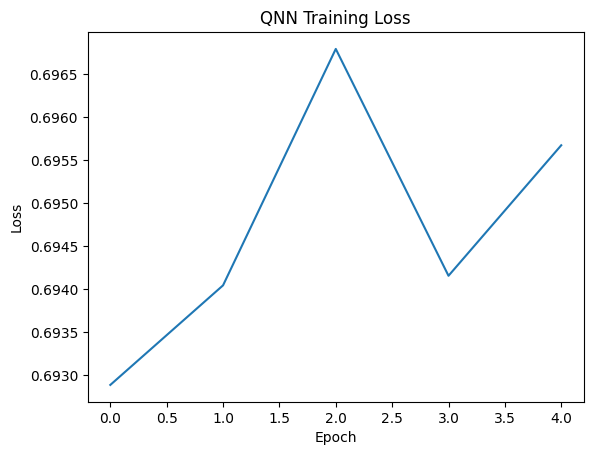

In [ ]:
# Plot training loss
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('QNN Training Loss')
plt.show()

In [ ]:
import numpy as np
import torch

from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.primitives import StatevectorSampler  # albo inny Sampler

# 1) Własna feature map (parametry wejściowe)
n_qubits = 4

feature_map = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    feature_map.h(i)
    feature_map.ry(np.cos(np.pi/2), i)

# 2) Ansatz (parametry wag)
theta = ParameterVector("θ", length=2*n_qubits)
ansatz = QuantumCircuit(n_qubits)
k = 0
for i in range(n_qubits):
    ansatz.rz(theta[k], i); k += 1
    ansatz.ry(theta[k], i); k += 1
for i in range(n_qubits - 1):
    ansatz.cx(i, i + 1)

# 3) Połączenie + pomiar
qc = QuantumCircuit(n_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)
qc.measure_all()

# 4) SamplerQNN: jawnie wskazujesz input_params i weight_params
sampler = StatevectorSampler()
qnn = SamplerQNN(
    circuit=qc,
    sampler=sampler,
    input_params=[],
    weight_params=list(ansatz.parameters),
    # opcjonalnie interpret/output_shape do klasyfikacji binarnej / wieloklasowej
)

# 5) TorchConnector
model = TorchConnector(qnn)

# forward: (batch, num_inputs) -> (batch, output_shape)
out = model(torch.tensor([[0.1, 0.2, 0.3, 0.4]], dtype=torch.float32))
print(out.shape)
